<a href="https://colab.research.google.com/github/Rounak105/MA-LAB-EXPERIMENTS/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objective
To predict whether a game will be played when the weather is 'sunny' using the Naive Bayes classification algorithm, based on the provided dataset.

## Method Used: Naive Bayes Classification

Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem with the 'naive' assumption of independence between features.

The core formula for Naive Bayes is:

$$P(C|X) = \frac{P(X|C)P(C)}{P(X)}$$

Where:
- $P(C|X)$: Posterior probability of class $C$ given predictor $X$.
- $P(X|C)$: Likelihood of predictor $X$ given class $C$.
- $P(C)$: Prior probability of class $C$.
- $P(X)$: Prior probability of predictor $X$.

In our case:
- $C$ refers to 'Play Game' (Yes or No).
- $X$ refers to 'Weather' (Sunny or Rainy).

We want to find $P(\text{Play Game=Yes} | \text{Weather=Sunny})$ and $P(\text{Play Game=No} | \text{Weather=Sunny})$ and choose the class with the higher probability.

## Data Representation
First, let's represent the given dataset using a pandas DataFrame.

In [ ]:
import pandas as pd

data = {
    'Weather': ['sunny', 'sunny', 'rainy', 'rainy'],
    'Play Game': ['yes', 'yes', 'no', 'no']
}
df = pd.DataFrame(data)

print("Our Dataset:")
display(df)

Our Dataset:


,Weather,Play Game
0,sunny,yes
1,sunny,yes
2,rainy,no
3,rainy,no


## Calculating Probabilities
We need to calculate the prior probabilities for 'Play Game' and the likelihoods of 'Weather' given 'Play Game'.

In [ ]:
# 1. Prior Probabilities P(Play Game)
p_play_yes = df[df['Play Game'] == 'yes'].shape[0] / df.shape[0]
p_play_no = df[df['Play Game'] == 'no'].shape[0] / df.shape[0]

print(f"P(Play Game=Yes): {p_play_yes:.2f}")
print(f"P(Play Game=No): {p_play_no:.2f}\n")

# 2. Likelihoods P(Weather | Play Game)
# For Play Game = Yes
df_yes = df[df['Play Game'] == 'yes']
p_sunny_given_yes = df_yes[df_yes['Weather'] == 'sunny'].shape[0] / df_yes.shape[0]

print(f"P(Weather=Sunny | Play Game=Yes): {p_sunny_given_yes:.2f}")

# For Play Game = No
df_no = df[df['Play Game'] == 'no']
p_sunny_given_no = df_no[df_no['Weather'] == 'sunny'].shape[0] / df_no.shape[0]

print(f"P(Weather=Sunny | Play Game=No): {p_sunny_given_no:.2f}\n")

# 3. Evidence P(Weather=Sunny)
p_sunny = df[df['Weather'] == 'sunny'].shape[0] / df.shape[0]
print(f"P(Weather=Sunny): {p_sunny:.2f}")

P(Play Game=Yes): 0.50
P(Play Game=No): 0.50

P(Weather=Sunny | Play Game=Yes): 1.00
P(Weather=Sunny | Play Game=No): 0.00

P(Weather=Sunny): 0.50


## Prediction: Game will be played when Weather = Sunny
Now, we apply the Naive Bayes formula to calculate the posterior probabilities for 'Play Game=Yes' and 'Play Game=No' when 'Weather=Sunny'.

In [ ]:
# Calculate Posterior Probabilities
# P(Play Game=Yes | Weather=Sunny) = P(Weather=Sunny | Play Game=Yes) * P(Play Game=Yes) / P(Weather=Sunny)
posterior_yes = (p_sunny_given_yes * p_play_yes) / p_sunny

# P(Play Game=No | Weather=Sunny) = P(Weather=Sunny | Play Game=No) * P(Play Game=No) / P(Weather=Sunny)
posterior_no = (p_sunny_given_no * p_play_no) / p_sunny

print(f"P(Play Game=Yes | Weather=Sunny): {posterior_yes:.2f}")
print(f"P(Play Game=No | Weather=Sunny): {posterior_no:.2f}\n")

# Make a prediction
if posterior_yes > posterior_no:
    prediction = 'Yes'
else:
    prediction = 'No'

print(f"Prediction: Based on Naive Bayes, if the weather is sunny, the game will be played: {prediction}")

P(Play Game=Yes | Weather=Sunny): 1.00
P(Play Game=No | Weather=Sunny): 0.00

Prediction: Based on Naive Bayes, if the weather is sunny, the game will be played: Yes


## Interpretation

- The prior probability of playing a game is 0.5, and not playing is also 0.5, indicating an equal chance without considering weather.
- When the weather is sunny, the likelihood of playing the game is 1.0 (meaning all sunny days in the past resulted in playing), while the likelihood of *not* playing is 0.0 (meaning no sunny days in the past resulted in not playing).
- As a result, the posterior probability of playing the game when it's sunny is 1.0, and not playing is 0.0.
- The Naive Bayes classifier assigns a probability of 100% to playing the game when the weather is sunny, based on the provided historical data.

## Conclusion
Using the Naive Bayes method on the given dataset, the model strongly predicts that the game **will be played** when the weather is sunny. This is because all instances where the weather was sunny in the training data corresponded to the game being played.

## Visualization
Let's visualize the posterior probabilities to clearly see the prediction.


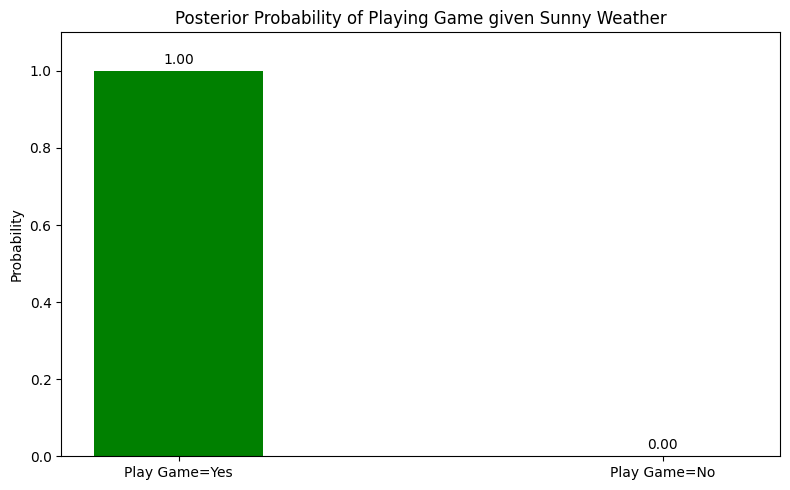

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
labels = ['Play Game=Yes', 'Play Game=No']
probabilities = [posterior_yes, posterior_no]
colors = ['green', 'red']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, probabilities, width, color=colors)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Probability')
ax.set_title('Posterior Probability of Playing Game given Sunny Weather')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1) # Set y-axis limit from 0 to 1 for probabilities

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

plt.tight_layout()
plt.show()